# Data Mining Lab 2
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
Энэхүү лабораторийн ажлыг дуусгасны дараа оюутан:
- Өгөгдлийн объект, аттрибутын тухай ойлголтыг бодит dataset дээр ашиглаж сурна  
- Статистик тайлбарлалтын аргуудыг (төв хандлага, хэлбэлзэл, тархалтын хэлбэр) тооцоолж чадна  
- Өгөгдлийг график аргаар зөв дүрслэнэ  
- Өгөгдлийн объектуудын хоорондын төсөө (similarity) ба ялгааг (dissimilarity) хэмжинэ  
- Нормализацийн аргуудыг (Min-Max, Z-score) ойлгож, хэрэглэнэ  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.



In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Өгөгдлийн объект ба аттрибут (Data Object & Attribute)

- Dataset дахь **мөр бүр** нэг өгөгдлийн объект (нэг оюутан) юм: x=(a₁, a₂, …, aₙ)  
- Dataset дахь **багана бүр** нэг аттрибут (feature)  

### 1.1 Dataset-ийн бүтэц
- Хэдэн объект (мөр), хэдэн аттрибут (багана) вэ?  
- Аль аттрибут numeric, аль нь categorical вэ?



In [3]:
print("Shape (objects, attributes):", df.shape)
print("Attributes:", list(df.columns))
df.dtypes


Shape (objects, attributes): (1000, 8)
Attributes: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль аттрибутад missing value байна вэ?  
- Давхардсан объект (мөр) байгаа эсэх?



In [4]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Numeric ба Categorical аттрибутууд



In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### TASK A: Аттрибутын хэмжээсийн түвшин (Measurement Level)

Лекцийн дагуу (**Nominal, Ordinal, Interval, Ratio**) доорх аттрибут бүрийг ангилж, шалтгаанаа бичнэ үү:

| Аттрибут | Төрөл (Nominal/Ordinal/Interval/Ratio) | Шалтгаан |
|---|---|---|
| gender | | |
| race/ethnicity | | |
| parental level of education | | |
| lunch | | |
| test preparation course | | |
| math score | | |
| reading score | | |
| writing score | | |

**Санамж:** score-ууд нь 0 цэгтэй (0 оноо = мэдлэггүй гэсэн үг биш ч бодит тоон утга) тул ихэвчлэн ratio гэж авч үздэг, харин `parental level of education` дараалалтай тул ordinal.



In [7]:
for col in cat_cols:
    print(col, df[col].nunique(), list(df[col].unique()))

gender 2 ['female', 'male']
race/ethnicity 5 ['group B', 'group C', 'group A', 'group D', 'group E']
parental level of education 6 ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
lunch 2 ['standard', 'free/reduced']
test preparation course 2 ['none', 'completed']


gender, race/ethnicity, lunch, test preparation course нь Nominal, parental level of education нь Ordinal, гурван score нь Ratio.

## 2) Статистик тайлбарлалт (Statistical Description)

### 2.1 Ерөнхий статистик



In [8]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 2.2 Төв хандлага: Mean, Median, Mode

- **Mean** — бүх утгыг ашигладаг ч outlier-д мэдрэмтгий  
- **Median** — эрэмбэлсэн дундах утга, outlier-д тэсвэртэй  
- **Mode** — хамгийн олон давтагдсан утга



In [9]:
for col in num_cols:
    print(f"{col:15s} mean={df[col].mean():.2f}  median={df[col].median():.2f}  mode={df[col].mode()[0]}")


math score      mean=66.09  median=66.00  mode=65
reading score   mean=69.17  median=70.00  mode=72
writing score   mean=68.05  median=69.00  mode=74


### 2.3 Хэлбэлзэл: Variance, Std



In [10]:
for col in num_cols:
    print(f"{col:15s} variance={df[col].var():.2f}  std={df[col].std():.2f}")


math score      variance=229.92  std=15.16
reading score   variance=213.17  std=14.60
writing score   variance=230.91  std=15.20


### 2.4 Тархалтын хэлбэр (Distribution Shape)

Лекц ёсоор:
- Symmetric: Mean ≈ Median ≈ Mode  
- Left-skewed: Mean < Median < Mode  
- Right-skewed: Mode < Median < Mean

Доорх код Mean ба Median-ийг харьцуулж, тархалтын хэлбэрийг тодорхойлно.



In [11]:
for col in num_cols:
    m, med = df[col].mean(), df[col].median()
    if abs(m - med) < 0.5:
        shape = "Symmetric"
    elif m < med:
        shape = "Left-skewed"
    else:
        shape = "Right-skewed"
    print(f"{col:15s} mean={m:.2f} median={med:.2f} -> {shape}")


math score      mean=66.09 median=66.00 -> Symmetric
reading score   mean=69.17 median=70.00 -> Left-skewed
writing score   mean=68.05 median=69.00 -> Left-skewed


## 3) Graphик дүрслэл (Visualization)

Лекцэд дурдсанчлан аттрибутын төрлөөс хамааран график сонгоно:

| Өгөгдөл | График |
|---|---|
| Categorical | Bar, Pie |
| Numerical | Histogram, Boxplot |
| Relationship | Scatter |



### 3.1 Bar chart – Categorical аттрибут (race/ethnicity)


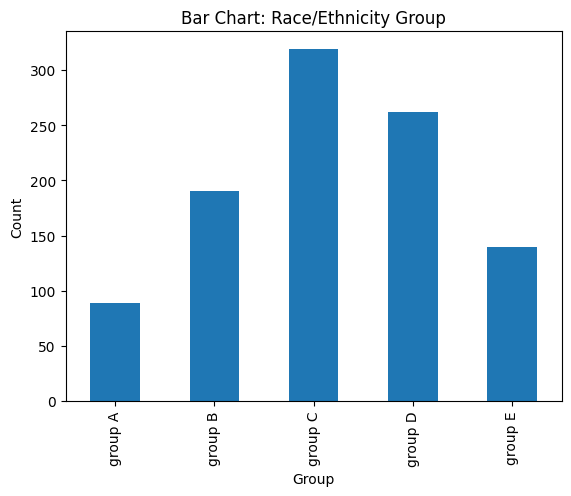

In [12]:
plt.figure()
df['race/ethnicity'].value_counts().sort_index().plot(kind='bar')
plt.title("Bar Chart: Race/Ethnicity Group")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()


### 3.2 Histogram – Reading score


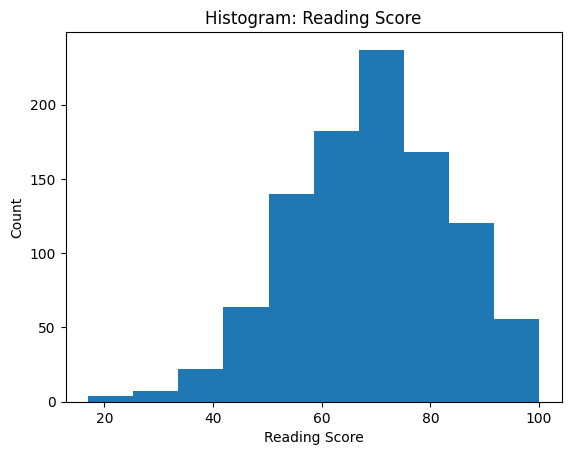

In [13]:
plt.figure()
plt.hist(df['reading score'], bins=10)
plt.title("Histogram: Reading Score")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()


### 3.3 Boxplot – Test preparation course vs Writing score


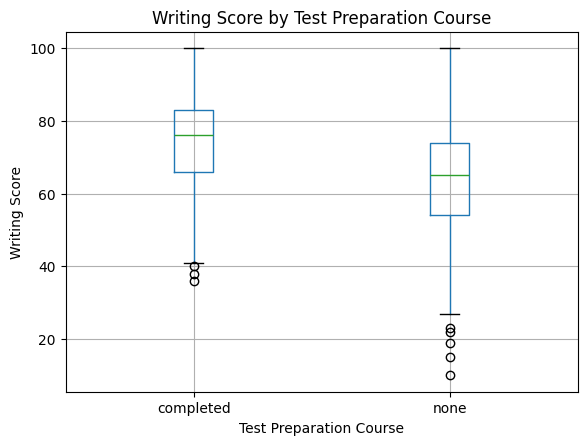

In [14]:
plt.figure()
df.boxplot(column='writing score', by='test preparation course')
plt.title("Writing Score by Test Preparation Course")
plt.suptitle("")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")
plt.show()


### 3.4 Scatter – Reading vs Writing score


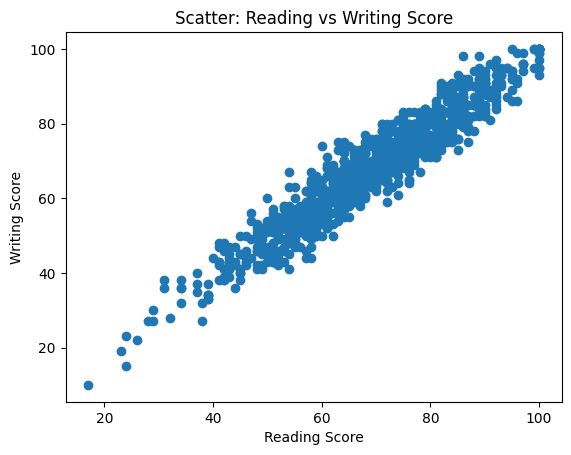

In [15]:
plt.figure()
plt.scatter(df['reading score'], df['writing score'])
plt.title("Scatter: Reading vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()


## 4) Төсөө ба ялгаа (Similarity & Dissimilarity)

- **Euclidean distance:** d(x,y) = sqrt(Σ(xᵢ - yᵢ)²)  
- **Manhattan distance:** d(x,y) = Σ|xᵢ - yᵢ|  

Доорх жишээнд эхний 3 оюутны (`math score`, `reading score`, `writing score`) утгуудыг ашиглан хос бүрийн зайг тооцооно.



In [16]:
from itertools import combinations

sample = df.loc[0:2, ['math score', 'reading score', 'writing score']]
sample.index = ['A', 'B', 'C']
sample


,math score,reading score,writing score
A,72,72,74
B,69,90,88
C,90,95,93


In [17]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

for i, j in combinations(sample.index, 2):
    a, b = sample.loc[i].values, sample.loc[j].values
    print(f"{i}-{j}:  Euclidean={euclidean(a, b):.2f}   Manhattan={manhattan(a, b):.2f}")


A-B:  Euclidean=23.00   Manhattan=35.00
A-C:  Euclidean=34.84   Manhattan=60.00
B-C:  Euclidean=22.16   Manhattan=31.00


### TASK B: Хамгийн төстэй оюутнууд

1. Дээрх гурван оюутны аль хос нь хамгийн бага Euclidean distance-той, өөрөөр хэлбэл хамгийн **төстэй** вэ?  
2. Manhattan distance-аар бодоход хариулт өөрчлөгдөж байна уу?  
3. Өөрийн сонгосон 3 өөр оюутнаар дахин тооцоолж, дүгнэлт хий.



In [18]:
sample2 = df.loc[3:5, ["math score", "reading score", "writing score"]]
sample2.index = ["D", "E", "F"]
print(sample2)
for i, j in combinations(sample2.index, 2):
    a, b = sample2.loc[i].values, sample2.loc[j].values
    print(f"{i}-{j}: Euclidean={euclidean(a, b):.2f}  Manhattan={manhattan(a, b):.2f}")

   math score  reading score  writing score
D          47             57             44
E          76             78             75
F          71             83             78
D-E: Euclidean=47.36  Manhattan=81.00
D-F: Euclidean=49.07  Manhattan=84.00
E-F: Euclidean=7.68  Manhattan=13.00


B-C хос хамгийн бага Euclidean distance = 22.16-тэй тул хамгийн төстэй. Manhattan-аар бодоход B-C хамгийн бага нь 31 тул хариулт өөрчлөгдөөгүй.

Өөрийн сонгосон 3 оюутан (3, 4, 5-р мөр): D (47, 57, 44), E (76, 78, 75), F (71, 83, 78). Эндээс E-F хамгийн төстэй = 7.68. D-ийн оноо бусдаасаа хамаагүй бага тул D нөгөө бүлгүүдээс нэлээд ялгаатай байна. Хоёр аргаар ижил хос гарсан.

## 5) Нормализаци (Normalization)

Яагаад хэрэгтэй вэ? Өөр өөр масштабтай аттрибутууд distance тооцооллыг гуйвуулахаас сэргийлнэ.

- **Min-Max normalization:** x' = (x - min) / (max - min)  
- **Z-score normalization:** x' = (x - mean) / std



In [19]:
scores = df[['math score', 'reading score', 'writing score']]

minmax = (scores - scores.min()) / (scores.max() - scores.min())
zscore = (scores - scores.mean()) / scores.std()

print("Min-Max normalized (эхний 5):")
display(minmax.head())
print("\nZ-score normalized (эхний 5):")
display(zscore.head())


Min-Max normalized (эхний 5):

Z-score normalized (эхний 5):


,math score,reading score,writing score
0,0.72,0.662651,0.711111
1,0.69,0.879518,0.866667
2,0.90,0.939759,0.922222
3,0.47,0.481928,0.377778
4,0.76,0.734940,0.722222


,math score,reading score,writing score
0,0.389828,0.193902,0.391296
1,0.191979,1.426762,1.312612
2,1.576922,1.769223,1.641653
3,-1.258913,-0.833482,-1.582952
4,0.653627,0.604855,0.457104


### TASK C: Нормализацийн нөлөө

1. Min-Max normalize хийсэн эхний 3 оюутны хооронд Euclidean distance-ийг дахин тооцоол.  
2. Normalize хийхээс өмнөх distance-тай харьцуулж, ялгааг тайлбарла (үгээр).  
3. Аль тохиолдолд normalization хийх нь **зайлшгүй шаардлагатай** вэ? (жишээ өг)



In [20]:
minmax3 = minmax.head(3)
minmax3.index = ["A", "B", "C"]
for i, j in combinations(minmax3.index, 2):
    a, b = minmax3.loc[i].values, minmax3.loc[j].values
    print(f"{i}-{j}: Euclidean={euclidean(a, b):.4f}")

A-B: Euclidean=0.2686
A-C: Euclidean=0.3921
B-C: Euclidean=0.2254


Нормализаци хийсний дараа Euclidean-ийн зай (0–1) хүрээнд орж, тоо нь хэд дахин багассан. Гэхдээ хосуудын эрэмбэ хэвээрээ B-C хамгийн ойрхон байна, учир нь гурван score бүгд (0–100)-ийн хооронд ratio хүрээтэй.

Аттрибутууд өөр өөр хүрээтэй үед нормализаци зайлшгүй хэрэгтэй.

## TASK D: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь math score-т хамгийн их ялгаа үүсгэж байна вэ?  
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол (`groupby()` + `mean()`).  
3. Гурван score-ийн дундаас аль нь хамгийн их **variance**-тай вэ, энэ нь юуг илэрхийлж болох вэ?



In [21]:
for col in ["gender", "lunch", "test preparation course"]:
    m = df.groupby(col)["math score"].mean()
    print(m)
    print("зөрүү:", round(m.max() - m.min(), 2), "\n")
print(df[["math score", "reading score", "writing score"]].var())

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64
зөрүү: 5.1 

lunch
free/reduced    58.921127
standard        70.034109
Name: math score, dtype: float64
зөрүү: 11.11 

test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64
зөрүү: 5.62 

math score       229.918998
reading score    213.165605
writing score    230.907992
dtype: float64


Lunch-аар ялгахад math score-ийн дундаж 11.11 оноогоор зөрж байгаа нь бусад хоёроос ойролцоогоор зөрүүгээрээ 2 дахин их байна. Хамгийн их variance-тай нь writing score = 230.91.

# Data Mining Lab 2 Тайлан
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл

**Нэр:** А.Сүхболд
**Оюутны код:** s22c055b
**Анги / Бүлэг:** CS-5
**Огноо:** 2026 он 9 сар 28 өдөр

---

## 1. Dataset-ийн ерөнхий мэдээлэл

Объектын мөрийн тоо: 1000

Аттрибутын багана тоо: 8

Тоон аттрибутууд: math score, reading score, writing score

Ангиллын аттрибутууд: gender, race/ethnicity, parental level of education, lunch, test preparation course

Дутуу өгөгдсөн утга болон давхардсан мэдээлэл, өгөгдөл алга байна.

---

## 2. Аттрибутын хэмжээсийн түвшин

Task A: Ангиллын аттрибутуудын төрөл болон тайлбар:

| Аттрибут | Төрөл | Тайлбар |
|---|---|---|
| gender | Nominal | female, male гэсэн хүйстэй (нэр дараалалгүй) |
| race/ethnicity | Nominal | group A–E бүлгүүд хоорондоо эрэмбэгүй, аль нэг бүлэг биенээсээ хамааралгүй. |
| parental level of education | Ordinal | Боловсролын түвшин эрэмбэтэй (high school < college < bachelor's < master's) |
| lunch | Nominal | standard, free/reduced гэсэн хоёр ангилалтай. |
| test preparation course | Nominal | completed, none гэсэн хоёр ангилалтай. |
| math score | Ratio | 0-ээс эхэлсэн тоон утга агуулна. |
| reading score | Ratio | 0-ээс эхэлсэн тоон утга агуулна. |
| writing score | Ratio | 0-ээс эхэлсэн тоон утга агуулна. |

---

## 3. Статистик тайлбарлалт

| Score | Дундаж | Медиан | Моод | Variance | Стандарт хазайлт |
|---|---|---|---|---|---|
| Math score | 66.09 | 66 | 65 | 229.92 | 15.16 |
| Reading score | 69.17 | 70 | 72 | 213.17 | 14.60 |
| Writing score | 68.05 | 69 | 74 | 230.91 | 15.20 |

Math score-ийн дундаж = 66.09 ба медиан = 66 ба бараг тэнцүү тул тархалт нь симметрик шинж чанартай байна. Reading болон writing score дээр дундаж нь медианаас бага (дундаж < медиан < моод) тул left-skewed хэлбэртэй буюу өөрөөр хэлбэл зүүн тийш цөөн хэдэн бага оноотой сүүлтэй байна.

Хамгийн их variance-тай нь writing score = 230.91. Энэ нь writing дээр оюутнуудын оноо хоорондоо хамгийн их зөрүүтэй гажууд утгатай гэсэн үг.

Task D Feature Analysis: Math score-т хамгийн их зөрүү үүсгэж байгаа feature нь lunch байна.

| Feature | Бүлэг 1 | Дундаж | Бүлэг 2 | Дундаж | Зөрүү |
|---|---|---|---|---|---|
| Lunch | standard | 70.03 | free/reduced | 58.92 | 11.11 |
| Test preparation course | completed | 69.70 | none | 64.08 | 5.62 |
| Gender | male | 68.73 | female | 63.63 | 5.10 |

Lunch-аар ялгахад math score-ийн дундаж 11.11 оноогоор зөрж байгаа нь бусад хоёроос ойролцоогоор зөрүүгээрээ 2 дахин их байна.

---

## 4. Дүрслэл

Bar chart (race/ethnicity): group C хамгийн олон 319, group A хамгийн цөөн 89 оюутантай байна.

Histogram (reading score): Ихэнх оюутан 60–80 оноонд төвлөрсөн, хамгийн олон нь 67–75 хооронд 237 оюутан байна. Зүүн хэсэгт бага оноотой цөөн оюутан харагдаж байна.

Boxplot (test preparation course vs writing score): Курсээ дүүргэсэн оюутнуудын медиан нь 76, дүүргээгүй нь 65 байна. Курс дүүргэсэн бүлгийн оноо бүхэлдээ өндөр дээгүүр байна.

Scatter (reading vs writing): Reading өндөр оюутан writing дээр ч өндөр, цэгүүд шулуун шугамын дагуу шугаман хамааралтай гарсан байна (корреляци = 0.955).

---

## 5. Төсөө ба ялгаа

Task B: Төстэй оюутнууд. Эхний гурван оюутан: A (72, 72, 74), B (69, 90, 88), C (90, 95, 93).

| Хос | Euclidean | Manhattan |
|---|---|---|
| A-B | 23.00 | 35 |
| A-C | 34.84 | 60 |
| B-C | 22.16 | 31 |

B-C хос хамгийн бага Euclidean distance = 22.16-тэй тул хамгийн төстэй. Manhattan-аар бодоход B-C хамгийн бага нь 31 тул хариулт өөрчлөгдөөгүй.

Өөрийн сонгосон 3 оюутан (3, 4, 5-р мөр): D (47, 57, 44), E (76, 78, 75), F (71, 83, 78).

| Хос | Euclidean | Manhattan |
|---|---|---|
| D-E | 47.36 | 81 |
| D-F | 49.07 | 84 |
| E-F | 7.68 | 13 |

Эндээс E-F хамгийн төстэй = 7.68. D-ийн оноо бусдаасаа хамаагүй бага тул D нөгөө бүлгүүдээс нэлээд ялгаатай байна. Хоёр аргаар ижил хос гарсан.

---

## 6. Нормализаци

Task C: Min-Max нормализаци хийсний дараах **Euclidean-ийн зай**:

| Хос | Өмнө | Min-Max дараа |
|---|---|---|
| A-B | 23.00 | 0.27 |
| A-C | 34.84 | 0.39 |
| B-C | 22.16 | 0.23 |

Нормализаци хийсний дараа Euclidean-ийн зай (0–1) хүрээнд орж, тоо нь хэд дахин багассан. Гэхдээ хосуудын эрэмбэ хэвээрээ B-C хамгийн ойрхон байна, учир нь гурван score бүгд (0–100)-ийн хооронд ratio хүрээтэй.

Аттрибутууд өөр өөр хүрээтэй үед нормализаци зайлшгүй хэрэгтэй.

---

## 7. Ерөнхий дүгнэлт

Csv файл dataset дээр pandas ашиглаад аттрибутын төрөл, дундаж, медиан, variance зэргийг тооцоолж үзлээ. Графикуудыг matplotlib-оор зурж, тархалт болон score хоорондын хамаарлыг харлаа. Оюутнуудын хоорондын зайг Euclidean, Manhattan-аар бодоод нормализаци хийхэд яаж өөрчлөгдөж байгааг харж дүгнэн бичлээ. Dataset нь цэвэрхэн байсан ч зай хэмжих, нормализаци хийх зэрэг зүйлсийг практикаар ойлгоход тус болж өглөө.